# Beamline Simulation Tutorial: Scripting with `shadow4`

*Bay Area Light Source Joint User Meeting, 2026*

**Contact:**
- Wei "Francis" He — francisho@lbl.gov
- Dr. Antoine Islegen-Wojdyla — awojdyla@lbl.gov

**Acknowledgements:** 

Beamline parameters are taken from the ALS-U COSMIC-U (7.0.1) optical design. 

---


## This Notebook

A single elliptical mirror: the simplest beamline that focuses the source to an image. We start from the Python script Oasys exports for it, work out what every line does, and then use it for something that is tedious in the GUI: a through-focus scan.

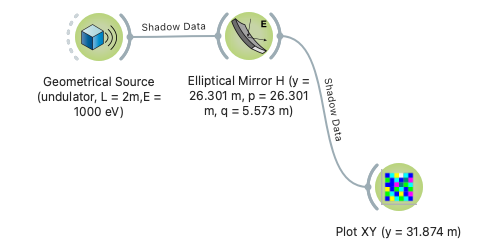

Source → horizontally focusing elliptical cylinder at 26.301 m (1.25° grazing) → screen at 31.874 m. 
### Contents

- **0. Setup** — packages and imports.
- **1. The script from Oasys** — the export, unchanged, and how any export is organised: `run_beamline()`, `S4Beamline`, the source block, the optical-element block, `# main`.
- **2. Retrace and plot** — what `beam` is, `retrace`, `histo2`, FWHM vs. σ.
- **3. Component breakdown** — source, mirror shape, placement and orientation, tracing; rebuilt piece by piece and checked ray for ray against the paste, then the orientation and alignment checks.
- **4. Through focus** — sweep the observation plane with `retrace` and map the beam through its waist, then watch the focus follow a mirror that has moved.

### Resources

- shadow4 source code and examples: [github.com/oasys-kit/shadow4](https://github.com/oasys-kit/shadow4)
- Oasys: [github.com/oasys-kit](https://github.com/oasys-kit)


## 0. Setup

Requirements: 
- A python environment (version >= 3.12 recommended)
- `shadow4` package
- Usual libraries such as `numpy`, `matplotlib`, ...

```bash
pip install shadow4 srxraylib
```

`shadow4` brings its own dependencies (`syned`, `dabax`) with it. 

In [1]:
from importlib.metadata import version

import numpy as np
import matplotlib.pyplot as plt

for pkg in ["shadow4", "syned", "srxraylib", "numpy", "matplotlib"]:
    print(f"{pkg:11s} {version(pkg)}")

shadow4     0.1.92
syned       1.0.57
srxraylib   1.0.69
numpy       2.5.3
matplotlib  3.11.2


## 1. The Script from Oasys

Output of the *Python Script* widget attached to the _Plot XY_ in the canvas above, unchanged.

> __Note:__ On the _Plot XY_ widget, select 'retraced' for 'Position of the image'. 

xraylib not available


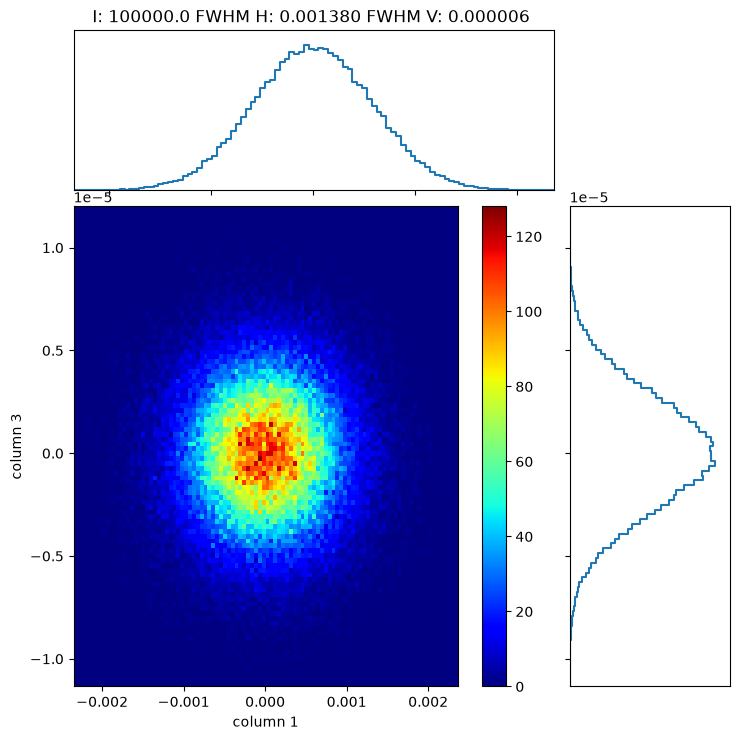

(<Figure size 800x800 with 4 Axes>,
 <Axes: xlabel='column 1', ylabel='column 3'>,
 <Axes: title={'center': 'I: 100000.0 FWHM H: 0.001380 FWHM V: 0.000006 '}>,
 <Axes: >)

In [2]:
import numpy as np

def run_beamline():
    footprint = None
    import numpy as np
    from dabax.dabax_xraylib import DabaxXraylib
    from shadow4.beamline.s4_beamline import S4Beamline
    
    beamline = S4Beamline()
    
    #
    #
    #
    from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical
    light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
    light_source.set_spatial_type_gaussian(sigma_h=1.65e-05,sigma_v=1.84e-05)
    light_source.set_depth_distribution_off()
    light_source.set_angular_distribution_gaussian(sigdix=1.86e-05,sigdiz=1.83e-05)
    light_source.set_energy_distribution_singleline(1000, unit='eV')
    light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
    beam = light_source.get_beam()
    
    beamline.set_light_source(light_source)
    
    # optical element number XX
    from syned.beamline.shape import Rectangle
    boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.126, y_top=0.126)
            
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror
    optical_element = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', boundary_shape=boundary_shape,
        surface_calculation=0, # 0=Internal calculation, 1=External 
        min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
        p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156, # for surface_calculation=0
        is_cylinder=1, cylinder_direction=0, convexity=1,
        f_reflec=0, # reflectivity of surface: 0=no reflectivity, 1=full polarization
        f_refl=0, # for f_reflec=1: file: 0=prerefl, 2=(mrad, refl), 3=(eV, refl), 4=(eV, mrad, refl); 1=refr index, 5=xraylib, 6=dabax
        file_refl='<none>', # for f_refl=0,2,3,4
        refraction_index=0.99999+0.001j, # for f_refl=1
        coating_material='Si', coating_density=2.33, # for f_refl=5,6
        coating_roughness=0, # for f_refl=0,1,5,6
        dabax=None # if using dabax (f_reflec=1,f_refl=6), instance of DabaxXraylib() (use None for default)
        )
    
    from syned.beamline.element_coordinates import ElementCoordinates
    coordinates = ElementCoordinates(p=26.301, q=5.573, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)
    movements = None
    from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirrorElement
    beamline_element = S4EllipsoidMirrorElement(optical_element=optical_element, coordinates=coordinates, movements=movements, input_beam=beam)
    
    beam, footprint = beamline_element.trace_beam()
    
    beamline.append_beamline_element(beamline_element)
    return beam, footprint

#
# main 
#
from srxraylib.plot.gol import plot, plot_image, plot_image_with_histograms, plot_show

# WARNING: NO incremental result allowed!!"
beam, footprint = run_beamline()
beam.retrace(0.000000)

ticket = beam.histo2(1, 3, nbins_h=100, nbins_v=100, xrange=[np.float64(-0.002373409266618813), np.float64(0.0023846403626897844)], yrange=[np.float64(-1.422164530542627e-05), np.float64(1.5035802610648317e-05)], nolost=1, ref=23)

title = "I: %.1f " % ticket['intensity']
if ticket['fwhm_h'] is not None: title += "FWHM H: %f " % ticket['fwhm_h']
if ticket['fwhm_v'] is not None: title += "FWHM V: %f " % ticket['fwhm_v']

plot_image_with_histograms(ticket['histogram'], ticket['bin_h_center'], ticket['bin_v_center'],
    title=title, xtitle="column 1", ytitle="column 3",
    cmap='jet', add_colorbar=True, figsize=(8, 8), histo_path_flag=1, show=1)

### How the script is organised

Every such `shadow4` export has the same shape:

```python
import numpy as np

def run_beamline():                      # builds AND traces the beamline
    beamline = S4Beamline()              # a record: one source + a list of elements

    # ── source ─────────────────────────
    light_source = SourceGeometrical(...)
    light_source.set_...(...)               # size, divergence, energy, polarization
    beam = light_source.get_beam()          # draw the rays
    beamline.set_light_source(light_source)

    # ── optical element (one block per optic) ──
    boundary_shape   = Rectangle(...)                   # aperture
    optical_element  = S4EllipsoidMirror(...)           # what the optic is
    coordinates      = ElementCoordinates(...)          # where it sits
    beamline_element = S4EllipsoidMirrorElement(...)    # optic + position + incoming beam
    beam, footprint  = beamline_element.trace_beam()    # rays go through this optic
    beamline.append_beamline_element(beamline_element)

    return beam, footprint

# main
beam, footprint = run_beamline()         # trace
beam.retrace(...)                        # choose the observation plane
ticket = beam.histo2(1, 3, ...)          # 2-D histogram of the beam
plot_image_with_histograms(...)          # draw it

```

The beamline is built by `run_beamline` function, within which source and optics are introduced by element blocks. To add more optics, simply stack more blocks. 

Tracing happens inside each element block by `trace_beam()`, which takes the beam arriving at the optic and returns the beam leaving it. 


## 2. Retrace and Plot

`# main` starts by running the whole beamline:

```python
beam, footprint = run_beamline()
```

`beam` is every ray that made it to the end. Everything after that line is a question we ask of those rays:

1. **`retrace`** — where do we want to look at them?
2. **`histo2`** — what does the beam look like there, and how big is it?

### 2.1 The `beam` and its `retrace`

`beam` is an object of shadow4's `S4Beam` class, holding rays (`beam.rays`) for tracing. Each ray 18 columns, of which the following are used in this notebook:

| Column | Python index | Content |
|---|---|---|
| 1, 2, 3 | 0, 1, 2 | position x, y, z [m] |
| 4, 5, 6 | 3, 4, 5 | direction: the unit vector the ray travels along |
| 10 | 9 | flag: positive = good, negative = lost on an aperture |

<br>

> __Notes: x, y and z are the beam's own frame__ — y along the direction of propagation, x and z transverse.
>
> At the source x is lab horizontal and z is lab vertical; each optic turns that pair with it (section 3.3).

In [3]:
# What run_beamline() handed back
print(type(beam).__name__, "with", beam.rays.shape[0], "rays x",
       beam.rays.shape[1], "columns")

good = beam.rays[:, 9] > 0          # column 10: the ray survived every aperture
print(f"\ngood rays: {good.sum()} of {good.size}")

# Column 2 is y: every ray sits on one plane, the screen. Columns 1 and 3 are the beam's
# cross-section there.
print(f"largest |y|:   {np.abs(beam.rays[good, 1]).max():.1e} m")
print(f"column 1 rms:  {beam.rays[good, 0].std() * 1e6:8.1f} µm")
print(f"column 3 rms:  {beam.rays[good, 2].std() * 1e6:8.1f} µm")

S4Beam with 100000 rays x 18 columns

good rays: 100000 of 100000
largest |y|:   0.0e+00 m
column 1 rms:     584.3 µm
column 3 rms:       2.8 µm


`beam.retrace(d_m)` traces every ray to the plane **y = `d_m`**, and updates the other 17 columns to match (positions, and the optical path each ray has travelled).

`y` is absolute, measured from wherever the current origin sits — here the image plane of the last optic. So `retrace(0.5)` followed by `retrace(-0.5)` does not undo anything: it leaves the rays 0.5 m *upstream* of the image plane. And `retrace` writes into `beam.rays`, so the previous positions are gone unless you work on a `beam.duplicate()`.

In [4]:
b = beam.duplicate()      # retrace overwrites the rays, so work on a copy

for d_m in [0.0, 0.5, -0.5, 0.0]:
    b.retrace(d_m)
    y_m = b.rays[b.rays[:, 9] > 0, 1]
    rms_m = b.rays[b.rays[:, 9] > 0, 2].std()
    print(f"retrace({d_m:+.1f})  ->  y = {y_m.mean():+.1f} m   column-3 rms = {rms_m * 1e6:8.1f} µm")

assert np.isclose(b.rays[b.rays[:, 9] > 0, 2].std(), beam.rays[good, 2].std(), rtol=1e-9)

retrace(+0.0)  ->  y = +0.0 m   column-3 rms =      2.8 µm
retrace(+0.5)  ->  y = +0.5 m   column-3 rms =     44.1 µm
retrace(-0.5)  ->  y = -0.5 m   column-3 rms =     43.9 µm
retrace(+0.0)  ->  y = +0.0 m   column-3 rms =      2.8 µm


### 2.2 Characterization with `histo2`

`histo2(col_h, col_v, ...)` bins the rays into the 2-D histogram the export plots and returns a dictionary — the *ticket* — with the image, its bin centres, the FWHM of each projection, and the intensity. `histo1` is the same thing for a single column.

| Argument | In the export | Meaning |
|---|---|---|
| `col_h`, `col_v` | 1, 3 | which columns go on the plot's horizontal and vertical axes |
| `nbins_h`, `nbins_v` | 100, 100 | bins per axis |
| `nolost` | 1 | leave out rays lost on apertures |
| `ref` | 23 | weight each ray by its intensity instead of counting rays |
| `xrange`, `yrange` | frozen numbers | limits in metres; leave them out and the histogram fits the rays. The export's are the GUI's autoscale values from export time, and they clip whatever grew since — delete them. |


The exported script plots "FWHM H = 1.4 mm" as vertical size, and "FWHM V = 8 µm" as the horizontal focus.

> **Notes: `col_h` and `col_v` name the plot's axes, not the lab's**; neither are `1` and `3`, who are defined with respect to the beam as explained above.  

#### FWHM and σ

Both describe the width of the same profile. For a Gaussian, one gives the other:

$$\mathrm{FWHM} = 2\sqrt{2\ln 2}\; \sigma \approx 2.355\,\sigma$$

They are measured differently: the ticket's FWHM is read off the binned profile, so it moves with `nbins`, while σ is computed from the rays themselves and does not.

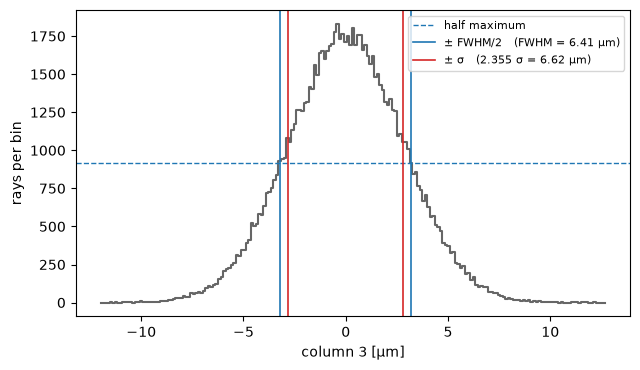

In [5]:
col3_m = beam.rays[good, 2]     # positions in the focusing direction
sigma_m = col3_m.std()

ticket = beam.histo2(1, 3, nbins_h=201, nbins_v=201, nolost=1, ref=23)
profile, centres_m = ticket["histogram"].sum(axis=0), ticket["bin_v_center"]   # the column-3 projection
fwhm_m = ticket["fwhm_v"]

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.step(centres_m * 1e6, profile, where="mid", color="0.4")
ax.axhline(profile.max() / 2, color="tab:blue", ls="--", lw=1, label="half maximum")
for s in (-1, 1):
    ax.axvline(s * fwhm_m / 2 * 1e6, color="tab:blue", lw=1.2,
               label=f"± FWHM/2   (FWHM = {fwhm_m * 1e6:.2f} µm)" if s == 1 else None)
    ax.axvline(s * sigma_m * 1e6, color="tab:red", lw=1.2,
               label=f"± σ   (2.355 σ = {2.3548 * sigma_m * 1e6:.2f} µm)" if s == 1 else None)
ax.set_xlabel("column 3 [µm]")
ax.set_ylabel("rays per bin")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# A binned FWHM lands a few percent below 2.355 σ.
assert np.isclose(fwhm_m, 2.3548 * sigma_m, rtol=0.05)

We can compare the beam size at focus between simulation and analytical analysis. 

In [6]:
p_m, q_m = 26.301, 5.573
sigma_source_h_m = 1.65e-5     # rms horizontal source size, from the source block [m]

print(f"traced:   {sigma_m * 1e6:.2f} µm rms")
print(f"expected: {sigma_source_h_m * q_m / p_m * 1e6:.2f} µm rms   (source size × q/p)")
assert np.isclose(sigma_m, sigma_source_h_m * q_m / p_m, rtol=0.02)

traced:   2.81 µm rms
expected: 2.82 µm rms   (source size × q/p)


## 3. Beamline Components

The same script, taken out of `run_beamline()` one block per cell, so every object stays around to inspect. Section 3.4 checks the rebuilt beam against the pasted one.

In [7]:
beam_paste = beam.duplicate()   # keep the pasted script's result for the comparison in 3.4

### 3.1 Source

`SourceGeometrical` draws rays from Gaussian distributions: a size in the source plane, an angular spread, and a photon energy. Its frame is **x horizontal, y along the beam, z vertical**, so `sigma_h`/`sigdix` are horizontal and `sigma_v`/`sigdiz` vertical.

The four numbers here stand in for the undulator at 1000 eV; Part 2 derives them and makes them functions of photon energy. The other calls have alternatives worth knowing about — several lines, uniform or Gaussian energy spectra, a source with depth, elliptical polarization — and the talk notes cover them.

In [8]:
from shadow4.sources.source_geometrical.source_geometrical import SourceGeometrical

light_source = SourceGeometrical(name='Geometrical Source (undulator, L = 2m,E = 1000 eV)', nrays=100000, seed=12)
light_source.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
light_source.set_depth_distribution_off()
light_source.set_angular_distribution_gaussian(sigdix=1.86e-05, sigdiz=1.83e-05)
light_source.set_energy_distribution_singleline(1000, unit='eV')
light_source.set_polarization(polarization_degree=1, phase_diff=0, coherent_beam=0)
beam = light_source.get_beam()

In [9]:
r = beam.rays
checks = [("size x",       r[:, 0].std(), 1.65e-5),
          ("size z",       r[:, 2].std(), 1.84e-5),
          ("divergence x", r[:, 3].std(), 1.86e-5),
          ("divergence z", r[:, 5].std(), 1.83e-5)]

for name, got, asked in checks:
    print(f"{name:13s} asked {asked * 1e6:5.2f}   got {got * 1e6:5.2f}   (µm or µrad)")
    assert np.isclose(got, asked, rtol=0.01)   # 100k rays: statistical error ~0.2 %

size x        asked 13.30   got 13.26   (µm or µrad)
size z        asked 15.60   got 15.62   (µm or µrad)
divergence x  asked 18.60   got 18.60   (µm or µrad)
divergence z  asked 18.30   got 18.32   (µm or µrad)


#### The seed

`seed` is the starting point of the random-number generator, and it is what makes a run repeatable. **`seed=0` means "don't set one"**: shadow4 leaves the generator wherever it happens to be, so every call draws different rays. Any other integer fixes the draw — same seed, same rays, every time.

In [10]:
def draw(seed):
    s = SourceGeometrical(nrays=1000, seed=seed)
    s.set_spatial_type_gaussian(sigma_h=1.65e-05, sigma_v=1.84e-05)
    return s.get_beam().rays

assert not np.array_equal(draw(0), draw(0))    # seed=0: different every call
print("seed=0  -> different rays each call")
assert np.array_equal(draw(12), draw(12))      # seed=12: identical every call
print("seed=12 -> identical rays")

seed=0  -> different rays each call
seed=12 -> identical rays


### 3.2 Mirror

An optic is described in its **own frame**: the surface lies in the x–y plane, **y along the mirror's length, x across it, z along the surface normal**.

- `Rectangle(x_left, x_right, y_bottom, y_top)` — clear aperture in that frame: 20 mm wide, 252 mm long. Rays landing outside are flagged lost.
- `surface_calculation=0` — Shadow builds the ellipse from `p_focus`, `q_focus` and `grazing_angle`.
- `is_cylinder=1`, `cylinder_direction=0` — curved along its length only, so it focuses in one direction. `is_cylinder=0` would be a full ellipsoid, focusing in both.
- `convexity=1` — the concave, focusing side faces the beam.
- `f_reflec=0` — perfect reflector: no ray loses intensity, and the `f_refl` / `coating_*` arguments below it are inert.

> `q_focus` belongs to the mirror's **shape** — where this ellipse focuses. Where you **observe** is `ElementCoordinates.q`, in 3.3. The export sets both to 5.573 m; nothing forces them to be equal.

In [11]:
from syned.beamline.shape import Rectangle
from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirror

boundary_shape = Rectangle(x_left=-0.01, x_right=0.01, y_bottom=-0.126, y_top=0.126)

optical_element = S4EllipsoidMirror(name='Elliptical Mirror H (y = 26.301 m, p = 26.301 m, q = 5.573 m)', boundary_shape=boundary_shape,
    surface_calculation=0,
    min_axis=2.000000, maj_axis=2.000000, pole_to_focus=1.000000,
    p_focus=26.301000, q_focus=5.573000, grazing_angle=0.0218166156,
    is_cylinder=1, cylinder_direction=0, convexity=1,
    f_reflec=0,
    f_refl=0, file_refl='<none>', refraction_index=0.99999+0.001j,
    coating_material='Si', coating_density=2.33, coating_roughness=0,
    dabax=None,
    )

### 3.3 Placement and orientation

`ElementCoordinates` carries five numbers: the distances `p` and `q` to and from the optic along the central ray, the incidence and exit angles `angle_radial` and `angle_radial_out` — measured **from the surface normal**, so 1.548979711 rad is π/2 − 1.25° — and `angle_azimuthal`, which rolls the optic about the incoming beam.

The azimuth is what sets the plane the beam is deflected in: 0 or π deflect vertically, π/2 or 3π/2 horizontally. That plane is what "H" and "V" mirror mean. A tangential cylinder focuses in its own deflection plane, so this mirror deflects **and** focuses horizontally.

The output frame follows the optic rather than the lab: after reflection, **column 3 lies in the deflection plane and column 1 across it**. Here that makes column 1 lab vertical (unfocused) and column 3 lab horizontal (focused). With more optics the azimuths accumulate, so this mapping has to be worked out for the whole chain — Parts 2 and 3 come back to it.

`movements` misaligns the optic from this nominal placement; 3.4 traces one.

In [12]:
from syned.beamline.element_coordinates import ElementCoordinates

coordinates = ElementCoordinates(p=26.301, q=5.573, angle_radial=1.548979711, angle_azimuthal=1.570796327, angle_radial_out=1.548979711)
movements = None     # no misalignment; 3.4 traces one

### 3.4 Element, trace, record

- `S4EllipsoidMirrorElement` joins three things: the optic (3.2), its placement (3.3), and the beam arriving at it (3.1). Every optic class has a matching `...Element` class.
- `trace_beam()` does the ray tracing and returns two beams: `beam`, the rays leaving the mirror, and `footprint`, where they hit it.
- `S4Beamline` collects the source and the elements. Tracing has already happened by the time an element is appended, so the record is there to be asked about the layout — `distances_summary()` prints the distances, the demagnification and the total deflection. The export throws it away; keep it.

In [13]:
from shadow4.beamline.s4_beamline import S4Beamline
from shadow4.beamline.optical_elements.mirrors.s4_ellipsoid_mirror import S4EllipsoidMirrorElement

beamline = S4Beamline()
beamline.set_light_source(light_source)

beamline_element = S4EllipsoidMirrorElement(optical_element=optical_element, coordinates=coordinates,
                                            movements=movements, input_beam=beam)
beam, footprint = beamline_element.trace_beam()

beamline.append_beamline_element(beamline_element)
print(beamline.distances_summary())

  ********  SUMMARY OF DISTANCES ********
   ** DISTANCES FOR ALL O.E. [m] **           
          OE         TYPE           p[m]           q[m]         src-oe     src-screen 
           1       MIRROR        26.3010         5.5730        26.3010        31.8740 

   ** FOCUSING ELEMENTS **           
        OE                SHAPE      p_foc      q_foc        1/M 
         1   EllipticalCylinder      26.30       5.57       4.72 

Sum of Alphas [deg]:         90.000 
Sum of Alphas Mod 180 [deg]: 90.000 
Sum of Alphas Mod 360 [deg]: 90.000 

Total deflection angle H =     0.043633 rad =     2.500 deg
Total deflection angle V =    -0.000000 rad =    -0.000 deg 



In [14]:
# The pasted `# main` ends with retrace(0.0). Tracing leaves y at ~1e-15 rather than
# exactly 0, and retrace(0) snaps it, so this line is needed for a bit-exact match.
beam.retrace(0.0)

assert np.array_equal(beam.rays, beam_paste.rays)
print("Rebuilt beam is identical to the pasted script's, ray for ray.")

Rebuilt beam is identical to the pasted script's, ray for ray.


#### Checking 3.3: orientation and movements

`trace_mirror()` below is the 3.4 cell with the azimuth and the movements as arguments. It reuses the rays from 3.1 and the mirror from 3.2.

In [15]:
from shadow4.beamline.s4_beamline_element_movements import S4BeamlineElementMovements

source_beam = beamline_element.get_input_beam()   # the rays from 3.1

def trace_mirror(angle_azimuthal=np.pi / 2, movements=None):
    coords = ElementCoordinates(p=26.301, q=5.573, angle_radial=1.548979711,
                                angle_azimuthal=angle_azimuthal, angle_radial_out=1.548979711)
    element = S4EllipsoidMirrorElement(optical_element=optical_element, coordinates=coords,
                                       movements=movements, input_beam=source_beam)
    out, _ = element.trace_beam()
    return out

def rms(b, col):
    # rms of a Shadow column (numbered from 1) over good rays
    return b.rays[b.rays[:, 9] > 0, col - 1].std()

def centroid(b, col):
    return b.rays[b.rays[:, 9] > 0, col - 1].mean()

**Orientation.** Trace the same mirror at azimuth π/2 and at 0, and plot the beam in **lab** coordinates. The mirror focuses in whichever plane it deflects in, so the line turns over. The numbers to match are the demagnified source, σ · q/p, in the focused direction, and √(σ² + (σ′L)²) in the other.

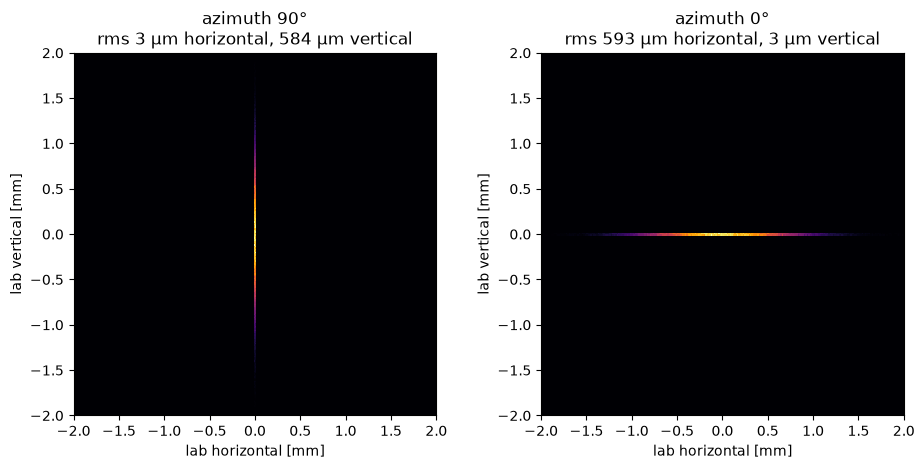

In [16]:
p_m, q_m = 26.301, 5.573
L_m = p_m + q_m
size_m  = {"horizontal": 1.65e-5, "vertical": 1.84e-5}   # source rms size [m]
div_rad = {"horizontal": 1.86e-5, "vertical": 1.83e-5}   # source rms divergence [rad]

focused     = lambda axis: size_m[axis] * q_m / p_m
not_focused = lambda axis: np.hypot(size_m[axis], div_rad[axis] * L_m)

# (azimuth, which column is lab horizontal, which is lab vertical)
cases = [(np.pi / 2, 3, 1), (0.0, 1, 3)]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
for ax, (az_rad, col_h, col_v) in zip(axes, cases):
    b = trace_mirror(angle_azimuthal=az_rad)
    g = b.rays[:, 9] > 0
    lab_h_m, lab_v_m = b.rays[g, col_h - 1], b.rays[g, col_v - 1]

    ax.hist2d(lab_h_m * 1e3, lab_v_m * 1e3, bins=250, range=[[-2, 2], [-2, 2]], cmap="inferno")
    ax.set_aspect("equal")
    ax.set_xlabel("lab horizontal [mm]")
    ax.set_ylabel("lab vertical [mm]")
    ax.set_title(f"azimuth {np.degrees(az_rad):.0f}°\n"
                 f"rms {lab_h_m.std() * 1e6:.0f} µm horizontal, {lab_v_m.std() * 1e6:.0f} µm vertical")

    # the focused direction is the demagnified source; the other is source + divergence over L
    if col_h == 3:
        assert np.isclose(lab_h_m.std(), focused("horizontal"), rtol=0.02)
        assert np.isclose(lab_v_m.std(), not_focused("vertical"), rtol=0.02)
    else:
        assert np.isclose(lab_v_m.std(), focused("vertical"), rtol=0.02)
        assert np.isclose(lab_h_m.std(), not_focused("horizontal"), rtol=0.02)
plt.tight_layout()
plt.show()

**Movements.** Pitch the mirror by 10 µrad. A mirror turns the reflected beam by twice its own rotation, so the image should move by 2θq across the deflection plane, and barely change size at this scale.

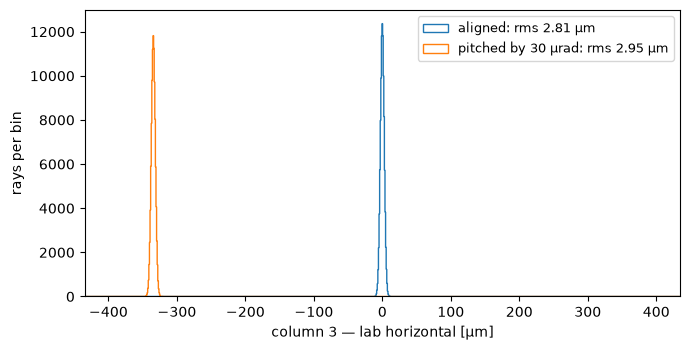

spot moves 334.4 µm   (2θq = 334.4 µm)


In [17]:
theta_rad = 30e-6   # pitch = 30 µrad

b_aligned = trace_mirror()
b_pitched = trace_mirror(movements=S4BeamlineElementMovements(f_move=1, rotation_x=theta_rad))
b_ignored = trace_mirror(movements=S4BeamlineElementMovements(f_move=0, rotation_x=theta_rad))

shift_m = centroid(b_pitched, 3) - centroid(b_aligned, 3)
span_um = 1.3 * abs(shift_m) * 1e6          # symmetric window, so the aligned image sits at the centre

fig, ax = plt.subplots(figsize=(7, 3.6))
for b, label in [(b_aligned, "aligned"), (b_pitched, f"pitched by {theta_rad * 1e6:.0f} µrad")]:
    col3_um = b.rays[b.rays[:, 9] > 0, 2] * 1e6
    ax.hist(col3_um, bins=1001, range=(-span_um, span_um), histtype="step",
            label=f"{label}: rms {col3_um.std():.2f} µm")
ax.set_xlim(-span_um, span_um)
ax.set_xlabel("column 3 — lab horizontal [µm]")
ax.set_ylabel("rays per bin")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"the image moves {abs(shift_m) * 1e6:.1f} µm   (2θq = {2 * theta_rad * q_m * 1e6:.1f} µm)")

assert np.isclose(abs(shift_m), 2 * theta_rad * q_m, rtol=0.01)
assert np.array_equal(b_ignored.rays, b_aligned.rays)   # f_move=0: the pitch is ignored

## 4. Through Focus

The beam at the screen is one plane out of many. Because the rays leave the last optic in straight lines, looking at another plane costs a `retrace` rather than a new trace — 61 of them together take about as long as the single trace that produced the beam. In the GUI it is 61 screen settings and 61 runs.

In [20]:
def at_plane(beam, dz_m):
    b = beam.duplicate()    # retrace overwrites the rays
    b.retrace(dz_m)
    return b

dz_list_m = np.linspace(-0.15, 0.15, 61)    # 5 mm steps
half_width_m = 40e-6                        # profile half-width, column 3 [m]
nbins = 201

rms_dz_m, profiles = [], []

for dz_m in dz_list_m:
    b = at_plane(beam, dz_m)
    x_m = b.rays[b.rays[:, 9] > 0, 2]       # column 3, the focusing direction
    rms_dz_m.append(x_m.std())
    profiles.append(np.histogram(x_m, bins=nbins, range=(-half_width_m, half_width_m))[0])

rms_dz_m = np.array(rms_dz_m)
profiles = np.array(profiles)               # rows: planes, columns: position bins

Stack the profiles and the beam draws its own caustic. Each plane is scaled to its own peak, otherwise the waist saturates and everything else goes black.

The dotted line is the straight-ray model,

$$\sigma(\Delta z) = \sqrt{\sigma_0^2 + (\sigma' \Delta z)^2}, \qquad \sigma_0 = \sigma_h \frac{q}{p}, \qquad \sigma' = \sigma'_h \frac{p}{q}$$

with $\sigma_0$ the demagnified source and $\sigma'$ the convergence angle. They are equal at $\Delta z = \sigma_0/\sigma'$, the depth of focus.

σ0 = 2.82 µm    σ' = 87.8 µrad    depth of focus = 32 mm


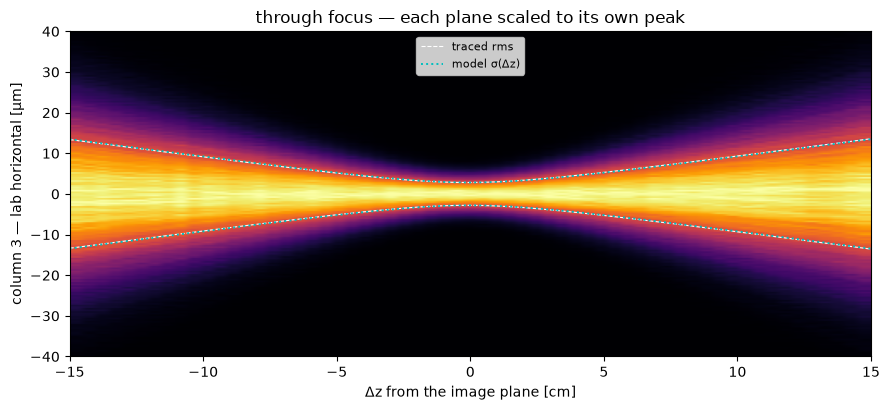

In [21]:
sigma0_m        = 1.65e-5 * q_m / p_m   # source image [m]
sigma_prime_rad = 1.86e-5 * p_m / q_m   # convergence at the image [rad]
sigma_model = lambda dz_m: np.sqrt(sigma0_m**2 + (sigma_prime_rad * dz_m)**2)

print(f"σ0 = {sigma0_m * 1e6:.2f} µm    σ' = {sigma_prime_rad * 1e6:.1f} µrad"
      f"    depth of focus = {sigma0_m / sigma_prime_rad * 1e3:.0f} mm")

fig, ax = plt.subplots(figsize=(9, 4.2))
img = profiles / profiles.max(axis=1, keepdims=True)
ax.imshow(img.T, origin="lower", aspect="auto", cmap="inferno",
          extent=[dz_list_m[0] * 100, dz_list_m[-1] * 100,
                  -half_width_m * 1e6, half_width_m * 1e6])
for sign in (+1, -1):
    ax.plot(dz_list_m * 100, sign * rms_dz_m * 1e6, "w--", lw=0.8,
            label="traced rms" if sign == 1 else None)
    ax.plot(dz_list_m * 100, sign * sigma_model(dz_list_m) * 1e6, "c:", lw=1.4,
            label="model σ(Δz)" if sign == 1 else None)
ax.legend(fontsize=8, loc="upper center")
ax.set_xlabel("Δz from the image plane [cm]")
ax.set_ylabel("column 3 — lab horizontal [µm]")
ax.set_title("through focus — each plane scaled to its own peak")
plt.tight_layout()
plt.show()

assert abs(dz_list_m[np.argmin(rms_dz_m)]) <= dz_list_m[1] - dz_list_m[0]   # waist at the image plane
for dz_m in (-0.15, -0.05, 0.05, 0.15):
    k = np.argmin(abs(dz_list_m - dz_m))
    assert np.isclose(rms_dz_m[k], sigma_model(dz_list_m[k]), rtol=0.03), dz_m

The same sweep answers an alignment question. Slide the mirror along its own length with `movements` — the optic moves along the beam, its conjugates change, and the focus travels with it. This one does re-trace, three times: the mirror has moved.

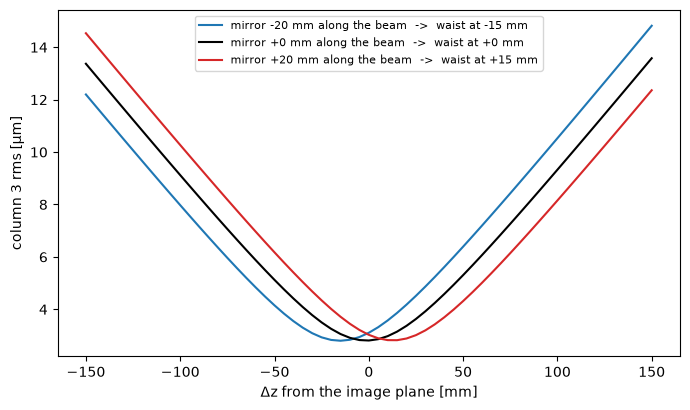

In [22]:
def through_focus(beam):
    # column-3 rms at every plane in dz_list_m
    sizes_m = []
    for dz_m in dz_list_m:
        b = at_plane(beam, dz_m)
        sizes_m.append(b.rays[b.rays[:, 9] > 0, 2].std())
    return np.array(sizes_m)

waist_m = {}

fig, ax = plt.subplots(figsize=(7, 4.2))
for offset_m, colour in [(-0.02, "tab:blue"), (0.0, "k"), (0.02, "tab:red")]:
    movement = None if offset_m == 0 else S4BeamlineElementMovements(f_move=1, offset_y=offset_m)
    curve_m = through_focus(trace_mirror(movements=movement))
    waist_m[offset_m] = dz_list_m[np.argmin(curve_m)]
    ax.plot(dz_list_m * 1e3, curve_m * 1e6, color=colour,
            label=f"mirror {offset_m * 1e3:+.0f} mm along the beam"
                  f"  ->  waist at {waist_m[offset_m] * 1e3:+.0f} mm")

ax.set_xlabel("Δz from the image plane [mm]")
ax.set_ylabel("column 3 rms [µm]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

assert waist_m[-0.02] < waist_m[0.0] < waist_m[0.02]   # the focus follows the mirror

## Wrap-up

One trace, 61 observation planes, a curve that matches a two-term formula, and an alignment answer from the same few lines — that is the case for scripting an export.

**Part 2** adds a second optic, a monochromator, and with it an energy axis: the export is frozen at one photon energy, and making it move takes a bit of physics.